# Data Analysis

# Clinic 3: Classification with missing values & inbalanced data

## DELIVERABLES (DEADLINE 06/Mar late night, wildcards possible)

Instructions for the deliverable: 

* Make sure that you include a proper amount/mix of comments, results and code.

* In the end, make sure that all cells are executed properly and everything you need to show is in your (execucted) notebook.

* You are asked to deliver **only your executed notebook file, .ipnyb** and nothing else. Enjoy!

* The second part of the assignment is purposefully left open-ended.

## Score breakdown

Question | Points
--- | ---
[Question 1](#q1) | 3
[Question 2](#q2) | 6
[Question 3](#q3) | 3
[Question 4](#q4) | 4
[Question 5](#q5) | 4
[Question 6](#q6) | 6
[Question 7](#q7) | 6
[Question 8](#q8) | 4
[Question 9](#q9) | 6
[Question 10](#q10)| 18
Total | 60

This score will be scaled down to 1 and that will be your final clinic score.

## Learning Goals

By the end of this clinic, you should be able to:

- Build classification models for credit default prediction
- Quantify and handle class imbalance
- Understand why accuracy fails in imbalanced settings
- Compare:
  - Accuracy
  - ROC-AUC
  - Precision-Recall AUC
  - Confusion matrices
- Use:
  - Cross-validation
  - Regularization
  - Class weighting
  - Threshold tuning

# 0. The dataset

### What is LendingClub?

LendingClub is a peer-to-peer lending platform that connects borrowers with investors. Instead of borrowing from a traditional bank, individuals apply for loans through the platform. Investors then fund these loans and receive returns if borrowers repay successfully.

The dataset used in this clinic contains historical loan data, including:

- Borrower characteristics
- Loan characteristics
- Credit risk indicators
- Loan repayment outcomes

Our goal is to predict whether a loan will **default**.

---

### What is the Prediction Task?

We focus on a binary classification problem:

- `default = 1` → Loan was **Charged Off** (borrower failed to repay)
- `default = 0` → Loan was **Fully Paid**

This is a classic **credit risk modeling** problem.

It is also a naturally **imbalanced dataset**, since most borrowers repay their loans.

### Structure of the Dataset

The dataset contains several categories of variables.

---

### 1️⃣ Borrower Employment & Income Information

- `emp_title` – Job title of the borrower  
- `emp_length` – Length of employment (in years)
- `annual_income` – Borrower’s reported annual income (in USD)
- `verified_income` – Whether income was verified (yes/no)
- `annual_income_joint` – Joint annual income (if co-borrower e.g. for couples)  
- `verification_income_joint` – Whether joint income was verified  
---

### 2️⃣ Housing & Application Information

- `state` – U.S. state of residence
- `homeownership` – three options: RENT / OWN / MORTGAGE  
- `application_type` – Individual or joint application  
- `loan_purpose` – Purpose of the loan (e.g., debt consolidation, credit card, car)  
---

### 3️⃣ Debt & Financial Burden Measures

- `debt_to_income` – Debt-to-income ratio
- `debt_to_income_joint` – Joint DTI (if applicable)  
- `installment` – Monthly loan payment (in USD)
- `loan_amount` – Total loan amount requested (in USD)
- `term` – Loan duration (in months)
- `interest_rate` – Interest rate assigned to the loan (in %)
---

### 4️⃣ Credit History Indicators

- `earliest_credit_line` – Year of first credit line  
- `delinq_2y` – Delinquencies in past 2 years (*delinquency* means failure to fulfill a financial obligation)
- `inquiries_last_12m` – Credit inquiries in last 12 months  
- `months_since_last_delinq` - months since ast delinquency 
- `months_since_90d_late` - a 90-day delinquency is a serious milestone in credit reporting
- `num_accounts_30d_past_due` - number of accounts that are 30 days past due
- `num_accounts_120d_past_due` - number of accounts that are 120 days past due
- `current_accounts_delinq` - number of accounts in delinquency
- `num_historical_failed_to_pay` - times that failed a payment in the past
- `public_record_bankrupt` - whether exists a public record for bankruptcy
- `tax_liens` - yes/no: a lien is a legal claim placed by some authority (usually public) against a person’s property 
---

### 5️⃣ Credit Utilization & Account Structure

- `total_credit_lines` - # of credit lines
- `open_credit_lines` - # of open credit ines
- `total_credit_limit` - credit limit (in USD)
- `total_credit_utilized` - credit used (in USD)
- `account_never_delinq_percent` - %
- `num_satisfactory_accounts` - # of accounts
- `num_open_cc_accounts` - # of accounts
- `num_cc_carrying_balance` - # credit cards carrying balance
- `num_active_debit_accounts` - # of accounts
- `total_debit_limit` - debit limit (in USD)
- `num_mort_accounts` - # of mortgage accounts
- `accounts_opened_24m` - # of accounts opened in the last 24 months
---

### 6️⃣ LendingClub Risk Grades

- `grade` – Risk category (A–G), internal assessment by LendingClub
- `sub_grade` – More granular risk classification, also by LendingClub
---

### 7️⃣ Loan Outcome Variables

- `balance` – Remaining balance  (in USD)
- `paid_total` – Total amount paid (in USD)
- `paid_principal` – Principal repaid (in USD)
- `paid_interest` – Interest paid (in USD)
- `paid_late_fees` – Late fees paid (in USD)
- `issue_month` – month/year of issue
- `initial_listing_status` – whole or functional  
- `disbursement_method` – How funds were disbursed 

- `default` – Final loan outcome (0 or 1) This is our prediction variable.

In [39]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.api import OLS
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
%matplotlib inline
import seaborn as sns
sns.set(context='paper')

In [40]:
# Load the loans dataset
loans = pd.read_csv('loans_full_schemaa.csv')

# Display basic information about the dataset
print(f"Dataset shape: {loans.shape}")
loans.head()

Dataset shape: (10000, 55)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees,default
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar/18,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0,0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb/18,whole,Cash,4651.37,499.12,348.63,150.49,0.0,0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb/18,fractional,Cash,1824.63,281.80,175.37,106.43,0.0,0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan/18,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0,0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar/18,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0,1


In [41]:
# Display column names and data types
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

## Part 1: Pre-processing

Before building any model, remove variables that would not have been known at the time the loan *was issued*. Using post-outcome information is called **data leakage** (which we covered in class) and leads to unrealistically high performance.

### Question 1: Data leakage

1. Which variables in this dataset must be excluded due to data leakage?
2. Why are they invalid predictors?
3. What would happen to model performance if you kept them?
4. Write code that would remove the variables from the dataframe.

Hint: Look for variables that describe repayment amounts, balances, late fees, or the final loan outcome.


**Your answer goes here**

In [42]:
###incude code where you remove the variabes causing the leakage
# 1) Remove leakage variables (post-outcome repayment information)
leakage_vars = ['paid_total', 'paid_principal', 'paid_interest', 'paid_late_fees','balance','issue_month']
leakage_vars = [c for c in leakage_vars if c in loans.columns]

print("Dropping leakage variables:", leakage_vars)
loans = loans.drop(columns=leakage_vars)


Dropping leakage variables: ['paid_total', 'paid_principal', 'paid_interest', 'paid_late_fees', 'balance', 'issue_month']



Missing % by column:
verification_income_joint           85.45
annual_income_joint                 85.05
debt_to_income_joint                85.05
months_since_90d_late               77.15
months_since_last_delinq            56.58
months_since_last_credit_inquiry    12.71
emp_title                            8.33
emp_length                           8.17
num_accounts_120d_past_due           3.18
debt_to_income                       0.24
public_record_bankrupt               0.00
num_open_cc_accounts                 0.00
num_total_cc_accounts                0.00
num_cc_carrying_balance              0.00
num_mort_accounts                    0.00
account_never_delinq_percent         0.00
tax_liens                            0.00
loan_amount                          0.00
loan_purpose                         0.00
application_type                     0.00
num_active_debit_accounts            0.00
term                                 0.00
interest_rate                        0.00
installment 

/var/folders/h6/5112162d7p9566r48ypkx9d00000gn/T/ipykernel_21238/2511318201.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_missing.values, y=top_10_missing.index, palette="magma")


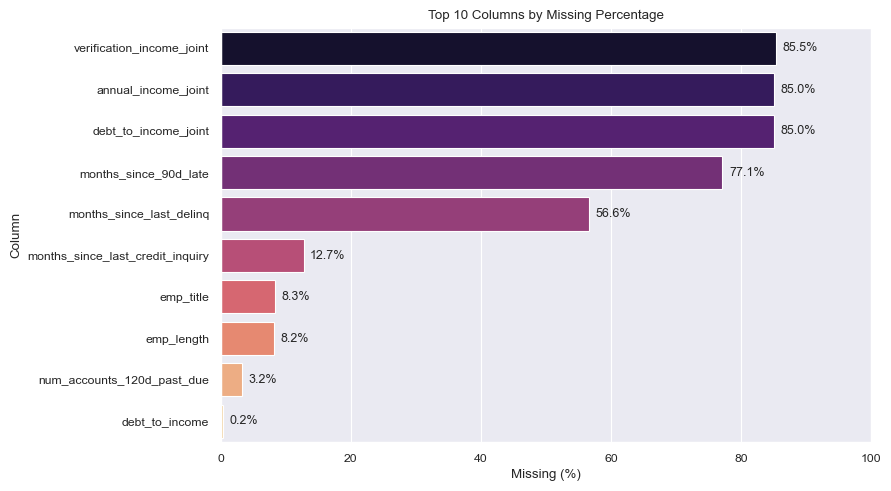

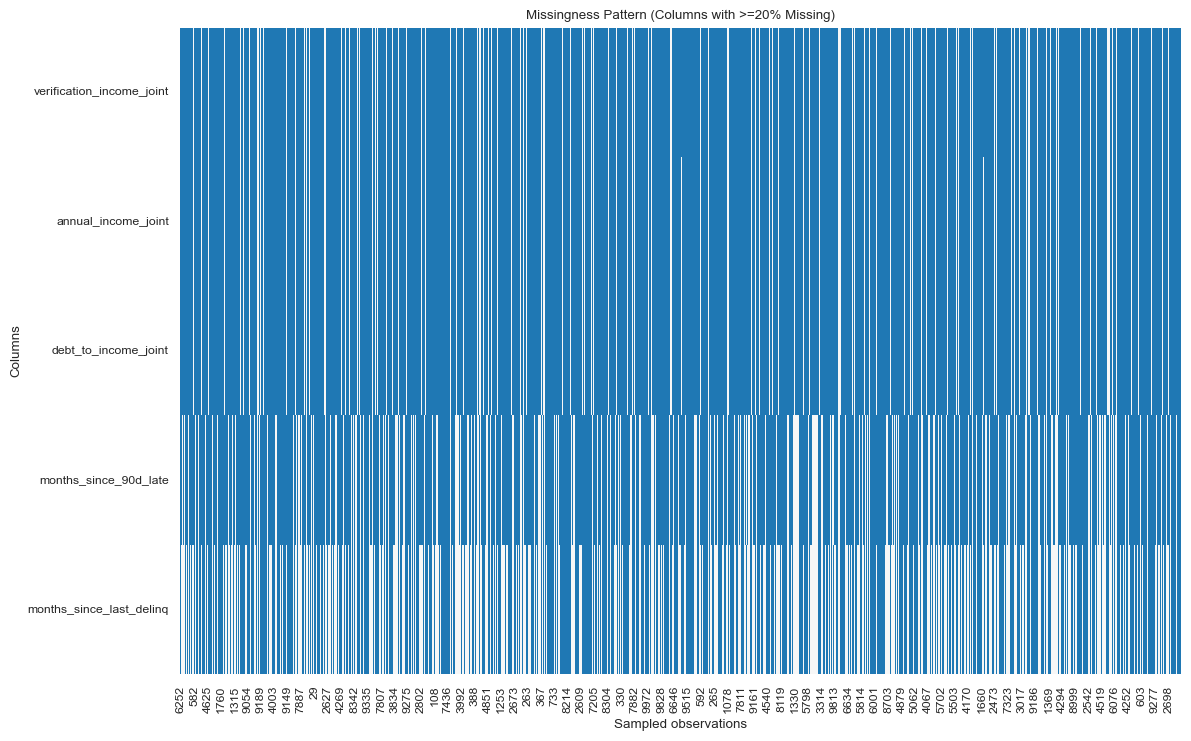

In [43]:




# 2) Missing values: percentages for each column
missing_percentages = loans.isna().mean().mul(100).sort_values(ascending=False)
missing_counts = loans.isna().sum().sort_values(ascending=False)

print("\nMissing % by column:")
print(missing_percentages)

# 3) Top 10 columns with highest missing %
top_10_missing = missing_percentages.head(10)
print("\nTop 10 columns by missing %:")
print(top_10_missing)

# 4) Visualization A: Top-10 missingness bar chart
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=top_10_missing.values, y=top_10_missing.index, palette="magma")
plt.title("Top 10 Columns by Missing Percentage")
plt.xlabel("Missing (%)")
plt.ylabel("Column")
plt.xlim(0, 100)

for i, val in enumerate(top_10_missing.values):
    ax.text(val + 1, i, f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# 5) Visualization B (bonus): Missingness heatmap for high-missing columns only
high_missing_cols = missing_percentages[missing_percentages >= 20].index.tolist()

if len(high_missing_cols) > 0:
    sampled_rows = loans.sample(n=min(1200, len(loans)), random_state=42).index
    plt.figure(figsize=(12, 1.1 * len(high_missing_cols) + 2))
    sns.heatmap(
        loans.loc[sampled_rows, high_missing_cols].isna().T,
        cmap=["#f7f7f7", "#1f78b4"],
        cbar=False
    )
    plt.title("Missingness Pattern (Columns with >=20% Missing)")
    plt.xlabel("Sampled observations")
    plt.ylabel("Columns")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo columns with missingness >= 20%.")

**Your answer goes here**

### 1. Which variables in this dataset must be excluded due to data leakage?

Based on the dataset, the primary variables that constitute data leakage are:

* `balance` (Current outstanding balance)
* `paid_total` (Total amount paid to date)
* `paid_principal` (Total principal paid to date)
* `paid_interest` (Total interest paid to date)
* `paid_late_fees` (Total late fees paid to date)

* `issue_month`  because it doesn't generalize well to future data rather than being pure "after-the-fact" leakage).

### 2. Why are they invalid predictors?

They are invalid predictors because they represent **future information** that you would absolutely not have at the exact moment you need to make the prediction.

[Image explaining data leakage in machine learning: training data vs production data]

A credit risk model is used at the *application phase* to decide: "Should we approve this loan or not?" At that moment, the applicant hasn't paid any principal, interest, or late fees yet, and their balance is zero. If you include variables that are updated *during the lifespan of the loan*, you are essentially letting your model "time travel" to look at the borrower's future payment behavior to predict if they will default.

### 3. What would happen to model performance if you kept them?

If you keep leakage variables in your dataset, you will experience the classic **"Too Good to Be True" illusion**.

* **During Training/Testing:** Your model's performance metrics (Accuracy, ROC-AUC, Precision, Recall) will shoot up to near 100%. The model will realize it doesn't need to look at complex things like `annual_income` or `credit_history`. It will simply learn a direct mathematical cheat code: *"If `paid_principal` is significantly lower than `loan_amount` and `paid_late_fees` > 0, then predict Default."*
* **During Real-World Production:** The model will fail catastrophically. When a new person applies for a loan, their `paid_late_fees` and `paid_principal` will be exactly $0. Since the model relies entirely on those "cheat code" variables to make its decision, it won't know how to evaluate a fresh application, leading to massive financial losses for the bank.


### Question 2: Analyze Missing Values

Now that we got rid of the "leakage" variables, it's important to understand the extent and pattern of missing data in the dataset.

1. Calculate the percentage of missing values for each column in the dataset.
2. Identify the top 10 columns with the highest percentage of missing values.
3. Create a proper visualization (bar plot or other) showing missing value patterns. We give bonus points if you come up with a suitable visualization going beyond the standard (which is still perfcetly fine)

Afterwards, discuss:

4. Which variables have substantial missingness (>20%)?

5. Are there any patterns in the missingness that could be informative (refer to the MAR, MNAR, MCAR concepts from week 1)?

6. How might you handle these missing values in your modeling pipeline? Implement some function to handle it on your dataframe.

7. Could the missingness itself be informative? (e.g., missing employment length might indicate self-employment)


Top 10 columns by missing percentage:
verification_income_joint           85.45
annual_income_joint                 85.05
debt_to_income_joint                85.05
months_since_90d_late               77.15
months_since_last_delinq            56.58
months_since_last_credit_inquiry    12.71
emp_title                            8.33
emp_length                           8.17
num_accounts_120d_past_due           3.18
debt_to_income                       0.24
dtype: float64


/var/folders/h6/5112162d7p9566r48ypkx9d00000gn/T/ipykernel_21238/2643109846.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_missing.values, y=top_10_missing.index, palette="viridis")


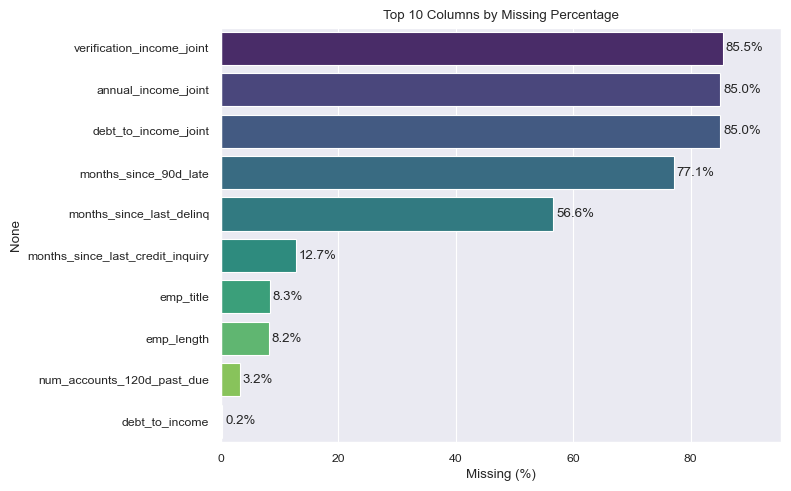

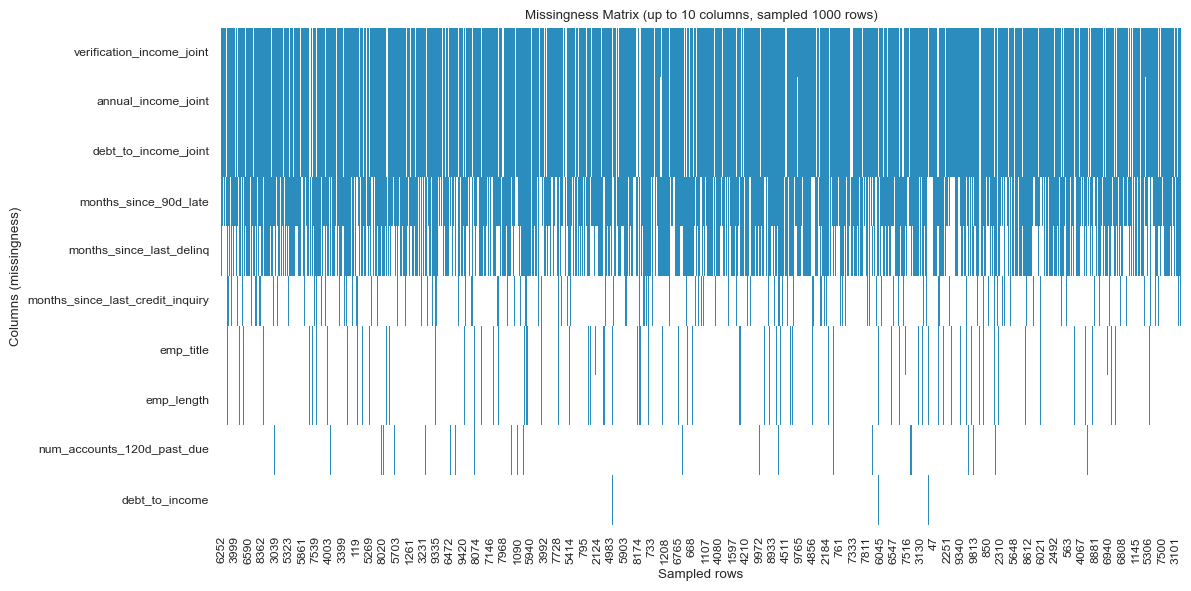

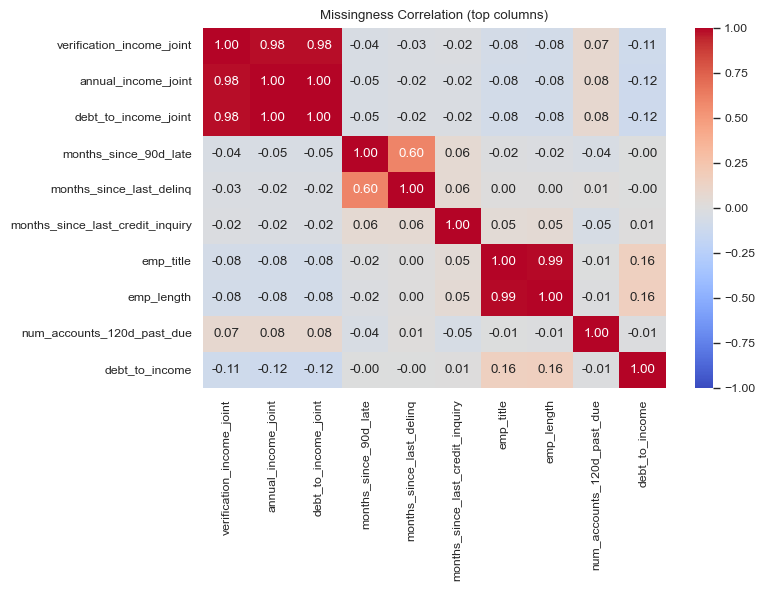


Total number of rows: 10000
Total number of columns: 49

Columns with missing values: 10
Columns with NO missing values: 39


In [44]:
# Your code here: Calculate and visualize missing values
#####################
# Hint: Use .isnull().sum() and .isnull().mean() * 100
#####################
# Calculate missing value counts and percentages
missing_counts = loans.isnull().sum()
missing_percentages = loans.isnull().mean() * 100

# 2. Top 10 columns with highest missing %
top_10_missing = missing_percentages.sort_values(ascending=False).head(10)

# Print summary (the cell already prints some info below; keep concise)
print("\nTop 10 columns by missing percentage:")
print(top_10_missing)

# 3. Visualizations

# Bar plot for top 10 missing columns
plt.figure(figsize=(8, 5))
sns.barplot(x=top_10_missing.values, y=top_10_missing.index, palette="viridis")
plt.xlabel("Missing (%)")
plt.title("Top 10 Columns by Missing Percentage")
for i, v in enumerate(top_10_missing.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')
plt.xlim(0, min(100, top_10_missing.values.max() + 10))
plt.tight_layout()
plt.show()

# Missingness matrix for a manageable subset of rows and columns
# Select columns that have any missingness, limit to top 30 most-missing columns for readability
cols_with_missing = missing_percentages[missing_percentages > 0].sort_values(ascending=False).index.tolist()
cols_to_plot = cols_with_missing[:30]  # limit to 30 columns for visualization clarity
n_rows_plot = min(len(loans), 1000)    # sample at most 1000 rows for performance

plt.figure(figsize=(12, 6))
sample_idx = loans.sample(n=n_rows_plot, random_state=42).index if len(loans) > n_rows_plot else loans.index
sns.heatmap(loans.loc[sample_idx, cols_to_plot].isnull().T, cbar=False, cmap=['#ffffff', '#2b8cbe'])
plt.xlabel("Sampled rows")
plt.ylabel("Columns (missingness)")
plt.title(f"Missingness Matrix (up to {len(cols_to_plot)} columns, sampled {len(sample_idx)} rows)")
plt.tight_layout()
plt.show()

# Optional: Missingness correlation heatmap among top missing columns (helps find patterns)
if len(cols_with_missing) >= 3:
    top_corr_cols = cols_with_missing[:20]  # limit to 20 for readability
    miss_corr = loans[top_corr_cols].isnull().corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(miss_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Missingness Correlation (top columns)")
    plt.tight_layout()
    plt.show()

# 1. Calculate the percentage of missing values for each column
missing_counts = loans.isnull().sum()
missing_percentages = loans.isnull().mean() * 100

print(f"\nTotal number of rows: {len(loans)}")
print(f"Total number of columns: {len(loans.columns)}")
print(f"\nColumns with missing values: {(missing_counts > 0).sum()}")
print(f"Columns with NO missing values: {(missing_counts == 0).sum()}")

The three joint‑income variables are missing only for individual applications (when application_type is not joint). This is a classic example of Missing At Random (MAR) – the missingness depends on another observed variable (application_type).

The delinquency‑related variables (months_since_last_delinq, months_since_90d_late) are missing when the borrower has no delinquency history. Here the missing value itself carries information (“no event”) and can be considered Missing Not At Random (MNAR) because the reason for missing is directly related to the value (absence of delinquency).

emp_title and emp_length are missing for some borrowers, possibly due to unemployment or self‑employment – this could be MAR if related to other employment indicators, or MCAR if completely random. The missingness heatmap shows no strong clustering, suggesting a mix.

how to handel misssing value
Drop columns with very high missingness (>80%) if they are not critical; but we can also keep them and create a “missing” indicator.

For joint‑income variables, we can create a binary flag is_joint_application (using application_type) and impute the missing values with 0.

For delinquency variables, we can replace missing values with a sentinel (e.g., –1 or a very large number) to indicate “no prior delinquency”, and also add a flag has_delinq_history.

For emp_length, we can impute with the median or mode.

For emp_title (high cardinality), if we drop it we may loss important information about the applicant but we can encode missingness with “unknown”.

Could missingness itself be informative?
Yes. For example, a missing value in months_since_last_delinq strongly suggests the borrower has never been delinquent – a positive signal for creditworthiness. Similarly, missing joint‑income variables indicate an individual applicant, which may be a different risk profile. Creating binary flags for missingness can therefore add predictive value.

In [45]:
# 4. Which variables have substantial missingness (>20%)?

# Reuse precomputed values if available
if 'missing_percentages' in globals():
    mp = globals()['missing_percentages'].copy()
else:
    # Pick an available dataframe without direct undefined-variable references
    base_df = globals().get('loans', None)
    if base_df is None:
        base_df = globals().get('loans_clean', None)

    if base_df is None:
        raise NameError("Neither `loans` nor `loans_clean` is defined. Run the data-loading/preprocessing cells first.")

    mp = base_df.isnull().mean() * 100
    missing_percentages = mp  # keep for later cells

substantial_missing = mp[mp > 20].sort_values(ascending=False)

print("\nColumns with substantial missingness (>20%):")
print(substantial_missing if not substantial_missing.empty else "None")


Columns with substantial missingness (>20%):
verification_income_joint    85.45
annual_income_joint          85.05
debt_to_income_joint         85.05
months_since_90d_late        77.15
months_since_last_delinq     56.58
dtype: float64


In [46]:
#here incude code to handle the missing values
import numpy as np
import pandas as pd

def handle_missing_values(loans):
    """
    Apply missing value handling strategies:
    - Joint income variables: fill with 0 and add is_joint_application flag.
    - Delinquency variables: fill missing with -1, add has_delinq_history flag.
    - months_since_last_credit_inquiry: fill with -1, add flag.
    - num_accounts_120d_past_due: fill with 0 (median), optional flag.
    - emp_length: fill with median.
    - emp_title: fill missing with 'unknown'.
    - debt_to_income: fill with median.
    - Drop columns with >80% missing (optional, here we keep them but handle as above).
    """
    df = loans.copy()

    # ----- Joint income variables (MAR, missing only for individual applications) -----
    # Create flag for joint application
    if 'application_type' in df.columns:
        df['is_joint_application'] = (df['application_type'] == 'Joint App').astype(int)
    else:
        # If application_type not present, derive from joint variables presence
        df['is_joint_application'] = df['annual_income_joint'].notna().astype(int)

    # Fill joint income variables with 0 (individual applicants have no joint income)
    for col in ['annual_income_joint', 'debt_to_income_joint', 'verification_income_joint']:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # ----- Delinquency variables (MNAR: missing means no delinquency history) -----
    delinq_cols = ['months_since_last_delinq', 'months_since_90d_late']
    for col in delinq_cols:
        if col in df.columns:
            df[f'has_{col}'] = df[col].notna().astype(int)
            df[col] = df[col].fillna(-1)   # sentinel for "no event"

    # ----- months_since_last_credit_inquiry (similar to delinquency) -----
    if 'months_since_last_credit_inquiry' in df.columns:
        df['has_months_since_last_credit_inquiry'] = df['months_since_last_credit_inquiry'].notna().astype(int)
        df['months_since_last_credit_inquiry'] = df['months_since_last_credit_inquiry'].fillna(-1)

    # ----- num_accounts_120d_past_due (low missing) -----
    if 'num_accounts_120d_past_due' in df.columns:
        # Optional flag, but we'll just impute with median (likely 0)
        median_val = df['num_accounts_120d_past_due'].median()
        df['num_accounts_120d_past_due'] = df['num_accounts_120d_past_due'].fillna(median_val)

    # ----- emp_length (employment length) -----
    if 'emp_length' in df.columns:
        # Fill with median (convert to float first)
        median_emp = df['emp_length'].median()
        df['emp_length'] = df['emp_length'].fillna(median_emp)

    # ----- emp_title (high cardinality categorical) -----
    if 'emp_title' in df.columns:
        # Fill missing with 'unknown'
        df['emp_title'] = df['emp_title'].fillna('unknown')
        # Option: keep as is; later you may use frequency encoding or one-hot

    # ----- debt_to_income (very low missing) -----
    if 'debt_to_income' in df.columns:
        median_dti = df['debt_to_income'].median()
        df['debt_to_income'] = df['debt_to_income'].fillna(median_dti)

    # ----- Additional columns that might have missing (like 'emp_title' already handled) -----
    # Any remaining numeric columns with missing values: fill with median
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    # Any remaining categorical columns with missing: fill with mode or 'missing'
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        if df[col].isnull().any():
            mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'missing'
            df[col] = df[col].fillna(mode_val)

    return df

# Apply the function
loans_clean = handle_missing_values(loans)

# Verify no missing values remain
print("Remaining missing values per column:\n", loans_clean.isnull().sum())



Remaining missing values per column:
 emp_title                               0
emp_length                              0
state                                   0
homeownership                           0
annual_income                           0
verified_income                         0
debt_to_income                          0
annual_income_joint                     0
verification_income_joint               0
debt_to_income_joint                    0
delinq_2y                               0
months_since_last_delinq                0
earliest_credit_line                    0
inquiries_last_12m                      0
total_credit_lines                      0
open_credit_lines                       0
total_credit_limit                      0
total_credit_utilized                   0
num_collections_last_12m                0
num_historical_failed_to_pay            0
months_since_90d_late                   0
current_accounts_delinq                 0
total_collection_amount_ever          

### Question 3: Quantify the Imbalance

We now focus on the binary variable `default`, which is the one we want to predict.

1. Compute the percentage of:
   - Defaulted loans 
   - Fully paid loans 
2. Which class is the majority?
3. Which class is the minority?
4. What would be the accuracy of a classifier that predicts all loans as Fully Paid?
5. Make an appropriate plot to show the class imbalance

In [47]:
# Q3: Class imbalance on target variable `default`

# 1) Percentages
class_counts = loans['default'].value_counts().sort_index()  # 0, 1
total = len(loans)

fully_paid_pct = (class_counts.get(0, 0) / total) * 100
defaulted_pct = (class_counts.get(1, 0) / total) * 100

print(f"Defaulted loans (default=1): {defaulted_pct:.2f}%")
print(f"Fully paid loans (default=0): {fully_paid_pct:.2f}%")

# 2) Majority class
majority_class = class_counts.idxmax()
majority_label = "Fully Paid" if majority_class == 0 else "Defaulted"
print(f"Majority class: {majority_label}")

# 3) Minority class
minority_class = class_counts.idxmin()
minority_label = "Fully Paid" if minority_class == 0 else "Defaulted"
print(f"Minority class: {minority_label}")

# 4) Accuracy of classifier that predicts all loans as Fully Paid (always 0)
naive_accuracy = fully_paid_pct / 100
print(f"Accuracy if always predict 'Fully Paid': {naive_accuracy:.4f} ({fully_paid_pct:.2f}%)")




Defaulted loans (default=1): 2.00%
Fully paid loans (default=0): 98.00%
Majority class: Fully Paid
Minority class: Defaulted
Accuracy if always predict 'Fully Paid': 0.9800 (98.00%)


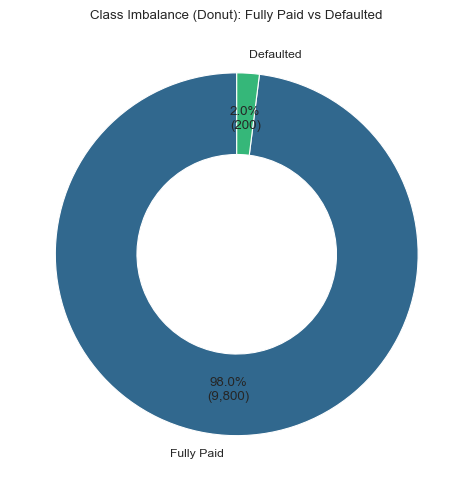

/var/folders/h6/5112162d7p9566r48ypkx9d00000gn/T/ipykernel_21238/1272525808.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=plot_df, order=['Fully Paid', 'Defaulted'], palette='viridis')


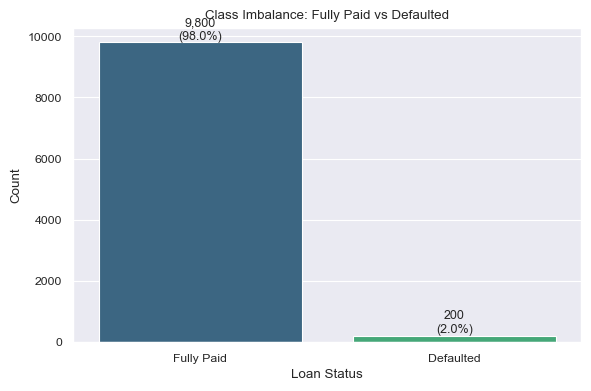

In [48]:
# Visualization: Class Distribution
 #5) Additional plot class imbalance (donut chart) — keep old plot below
labels = ['Fully Paid', 'Defaulted']
sizes = [class_counts.get(0, 0), class_counts.get(1, 0)]
colors = sns.color_palette('viridis', 2)

plt.figure(figsize=(5, 5))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p*total/100)):,.0f})",
    pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor='white')
)
plt.title('Class Imbalance (Donut): Fully Paid vs Defaulted')
plt.tight_layout()
plt.show()
plot_df = loans['default'].map({0: 'Fully Paid', 1: 'Defaulted'})

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=plot_df, order=['Fully Paid', 'Defaulted'], palette='viridis')
plt.title('Class Imbalance: Fully Paid vs Defaulted')
plt.xlabel('Loan Status')
plt.ylabel('Count')

for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(f"{count:,}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Your answer goes here**

Defaulted loans (default=1): 2.00%

Fully paid loans (default=0): 98.00%

Majority class: Fully Paid

Minority class: Defaulted

Accuracy if always predict 'Fully Paid': 0.9800 (98.00%)

### Question 4: Why Accuracy Fails

1. Why is accuracy not an appropriate metric in this dataset?
2. In credit lending, we assume that the cost of missing a default (i.e. lose an entire loan because a bad decision to hand out the loan was made) is approx. and on average 10,000 USD and the cost of rejecting a good borrower (i.e. the lost profit for rejecting a loan that would pay in ful) is 500 USD. Which is more costly:

   - A False Negative (missed defaulter)?
   - A False Positive (rejected good borrower)?
   
   Support your conclusions with calculations and plots.
   
3. Which metric would better reflect business risk?

**Your answer goes here**

### 1. The Accuracy Fallacy (The Numbers)

In a balanced dataset (50/50), accuracy tells you how "correct" you are. In an imbalanced dataset (98/2), accuracy only tells you how well you can identify the majority class.

If you have a dataset of **10,000 loans**:

* **9,800** are "Fully Paid" (98%)
* **200** are "Defaulted" (2%)

If your model is "lazy" and predicts everyone will pay back:

* **Correct Predictions:** 9,800
* **Accuracy:** $9,800 / 10,000 = \mathbf{98\%}$

On paper, **98%** looks like good accuracy. In reality, across these 10,000 applications, you just lost **$2,000,000** (200 defaults × $10,000) because your model failed to catch a single "bad" borrower.

---

### 2. Cost Analysis: False Negatives vs. False Positives

To understand business risk, we must calculate the cost of being wrong:

* **False Negative (FN):** You predict "Safe," but they default.
* **Cost:** **$10,000** (Loss of loan principal)


* **False Positive (FP):** You predict "Default," but they were a good borrower.
* **Cost:** **$500** (Lost interest profit)



**Conclusion:** A False Negative is **20 times more costly** than a False Positive. Missing one bad borrower wipes out the profit from 20 good ones.

---

### 3. Which metric better reflects business risk?

Since the goal is to protect the bank's capital, we move away from accuracy and toward metrics that prioritize the 2% minority:

1. **Recall (Sensitivity):** This is your primary **"Defense"** metric. It measures what percentage of the actual defaulters you successfully identified. A high recall means you avoided more of those $10,000 losses.
   
3. **F-Beta Score ($\beta=2$):** This is a balanced metric that gives **Recall** twice as much weight as Precision. It mathematically aligns the model's goals with your 20:1 cost ratio.
4. **PR-AUC (Precision-Recall Area Under Curve):** Unlike a standard ROC curve, PR-AUC focuses specifically on the performance of the minority class (Defaults). It provides a single score representing how well the model handles the "needle in the haystack."


In [49]:
#calculations for the cost

def calculate_business_loss(y_true, y_pred, cost_fn=10000, cost_fp=500):
    # Create a confusion matrix
    tp = np.sum((y_true == 1) & (y_pred == 1)) # Caught a default
    fn = np.sum((y_true == 1) & (y_pred == 0)) # Missed a default
    fp = np.sum((y_true == 0) & (y_pred == 1)) # Rejected good borrower
    tn = np.sum((y_true == 0) & (y_pred == 0)) # Approved good borrower
    
    total_loss = (fn * cost_fn) + (fp * cost_fp)
    return total_loss, {"TP": tp, "FN": fn, "FP": fp, "TN": tn}

# Simulation: 10,000 loans, 200 defaults (2%)
y_true = np.array([1]*200 + [0]*9800)
# Naive Model (Predicts 0 for everyone)
y_pred_naive = np.zeros(10000)

loss, matrix = calculate_business_loss(y_true, y_pred_naive)
print(f"Total Loss for Naive Model for 10,000 loans: ${loss:,}")
#ideas: consider the amounts of FP and FN (given the dataset) or even extreme classifiers (e.g. giving all loans)

Total Loss for Naive Model for 10,000 loans: $2,000,000


### Question 5: Identify Valid Features

1. We are now considering the rest of the features (after removing leakage variables).

   Identify which features are:
   - Numerical?
   - Categorical?
   - Ordinal?

2. Which categorical variables need encoding?

3. Are there any variabes with high cardinality (i.e. high number of categories) that you woud consider removing?

In [50]:
import pandas as pd
import numpy as np

def sort_features(df):
    # 1. Manually we define the Ordinal columns we recognizes 
    
    ordinal_cols_list = ['grade', 'sub_grade']
    
    # Check which ordinal columns are actually in the dataframe
    ordinal_features = [col for col in ordinal_cols_list if col in df.columns]

    # 2. Identify Numerical columns 
    # (Selects float64 and int64 data types)
    numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
    

    # 3. Identify Categorical (Nominal) columns
    # (Selects object/string types, then removes the ones we defined as ordinal)
    all_object_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    categorical_features = [col for col in all_object_cols if col not in ordinal_features]

    # Print the results nicely
    print(f"--- 🔢 NUMERICAL FEATURES ({len(numerical_features)}) ---")
    print(numerical_features)
    print("\n")
    
    print(f"--- 🔠 CATEGORICAL (NOMINAL) FEATURES ({len(categorical_features)}) ---")
    print(categorical_features)
    print("\n")
    
    print(f"--- 📊 ORDINAL FEATURES ({len(ordinal_features)}) ---")
    print(ordinal_features)
    
    return numerical_features, categorical_features, ordinal_features

# Run the function 
num_cols, cat_cols, ord_cols = sort_features(loans_clean)

--- 🔢 NUMERICAL FEATURES (42) ---
['emp_length', 'annual_income', 'debt_to_income', 'annual_income_joint', 'debt_to_income_joint', 'delinq_2y', 'months_since_last_delinq', 'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines', 'total_credit_limit', 'total_credit_utilized', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'months_since_90d_late', 'current_accounts_delinq', 'total_collection_amount_ever', 'current_installment_accounts', 'accounts_opened_24m', 'months_since_last_credit_inquiry', 'num_satisfactory_accounts', 'num_accounts_120d_past_due', 'num_accounts_30d_past_due', 'num_active_debit_accounts', 'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts', 'num_cc_carrying_balance', 'num_mort_accounts', 'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt', 'loan_amount', 'term', 'interest_rate', 'installment', 'default', 'is_joint_application', 'has_months_since_last_delinq', 'has_months_since_90d_late', 

In [51]:
import pandas as pd

def check_cardinality(df):
    print("=========================================")
    print("4. CARDINALITY CHECK (Categorical/Object columns)")
    print("=========================================")
    
    # Select only text/categorical columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    
    # Calculate unique values for each categorical column
    cardinality_list = []
    for col in cat_cols:
        unique_count = df[col].nunique()
        cardinality_list.append({'Column': col, 'Unique_Values': unique_count})
        
    # Create DataFrame, sort descending, and reset index
    cardinality_df = pd.DataFrame(cardinality_list)
    cardinality_df = cardinality_df.sort_values(by='Unique_Values', ascending=False).reset_index(drop=True)
    
    print("Variables with potentially HIGH cardinality (Consider dropping or grouping):")
    print(cardinality_df)
    
    return cardinality_df

# Example of how to run it:
cardinality_df = check_cardinality(loans_clean)

4. CARDINALITY CHECK (Categorical/Object columns)
Variables with potentially HIGH cardinality (Consider dropping or grouping):
                       Column  Unique_Values
0                   emp_title           4742
1                       state             50
2                   sub_grade             32
3                loan_purpose             12
4                       grade              7
5   verification_income_joint              4
6               homeownership              3
7             verified_income              3
8            application_type              2
9      initial_listing_status              2
10        disbursement_method              2


**Your answer goes here**

We are now considering the rest of the features (after removing leakage variables).


### Identify which features are: Numerical? Categorical? Ordinal?

**--- 🔢 NUMERICAL FEATURES (43) ---**
These features are continuous or discrete numbers and are already in a format the model can process (though scaling may be required later):

* `emp_length`, `annual_income`, `debt_to_income`, `annual_income_joint`, `debt_to_income_joint`, `delinq_2y`, `months_since_last_delinq`, `earliest_credit_line`, `inquiries_last_12m`, `total_credit_lines`, `open_credit_lines`, `total_credit_limit`, `total_credit_utilized`, `num_collections_last_12m`, `num_historical_failed_to_pay`, `months_since_90d_late`, `current_accounts_delinq`, `total_collection_amount_ever`, `current_installment_accounts`, `accounts_opened_24m`, `months_since_last_credit_inquiry`, `num_satisfactory_accounts`, `num_accounts_120d_past_due`, `num_accounts_30d_past_due`, `num_active_debit_accounts`, `total_debit_limit`, `num_total_cc_accounts`, `num_open_cc_accounts`, `num_cc_carrying_balance`, `num_mort_accounts`, `account_never_delinq_percent`, `tax_liens`, `public_record_bankrupt`, `loan_amount`, `term`, `interest_rate`, `installment`, `default`, `is_joint_application`, `has_months_since_last_delinq`, `has_months_since_90d_late`, `has_months_since_last_credit_inquiry`

**--- 🔠 CATEGORICAL (NOMINAL) FEATURES (10) ---**
These features contain text categories with no intrinsic mathematical order:

* `emp_title`, `state`, `homeownership`, `verified_income`, `verification_income_joint`, `loan_purpose`, `application_type`, `initial_listing_status`, `disbursement_method`

**--- 📊 ORDINAL FEATURES (2) ---**
These features contain categories that have a specific, meaningful rank or hierarchy:

* `grade`, `sub_grade`

---

### Which categorical variables need encoding?

Assuming we are not dropping any columns, **all 12 categorical and ordinal variables require encoding**. Machine learning models can only compute mathematical equations; they cannot read text strings.

The type of encoding depends on the feature's nature:

**1. Requires One-Hot Encoding (Nominal):**
These 10 variables will be split into binary (0 or 1) dummy columns to prevent the model from assuming one category is "greater" than another.

* `emp_title`, `state`, `homeownership`, `verified_income`, `verification_income_joint`, `loan_purpose`, `application_type`, `issue_month`, `initial_listing_status`, `disbursement_method`

**2. Requires Ordinal/Label Encoding (Ordinal):**
These 2 variables will be mapped to ascending integers (e.g., A = 1, B = 2) so the model understands the inherent risk ranking.

* `grade`, `sub_grade`

---

### Are there any variables with high cardinality (i.e. high number of categories) that you would consider removing?

Yes. Once we move from theory to practical model building, we should drop nominal variables with excessively high cardinality. If we apply a threshold of dropping nominal variables with more than 5 dimensions, we avoid the "Curse of Dimensionality" (where one-hot encoding creates hundreds or thousands of useless, sparse columns).

You should consider removing:

1. **`emp_title` (4,742 unique values):** This is extreme cardinality. One-hot encoding this would add nearly 5,000 columns of noisy, inconsistent text data, which would severely degrade model performance and cause overfitting.
2. **`state` (50 unique values):** While this is standard geographic data, adding 50 columns exceeds our low-dimensionality threshold. For simpler models (like Logistic Regression), it is better to drop it or group it into broader regions.
3. **`loan_purpose` (12 unique values):** This exceeds the threshold of 5 and should be dropped or grouped into broader categories (e.g., "Debt Consolidation" vs. "Other").

*(Note: `grade` (7) and `sub_grade` (32) also have high unique counts, but because they are **ordinal**, we keep them. Ordinal encoding keeps them in a single column, bypassing the dimensionality problem entirely.)*



## Part 2: Fit a logistic model ignoring missing values

Now by this point, we assume that you have dealt with missing values, possible data leakage and have done some first pre-processing decisions. Feel free to continue the exploration here, but keep in ind that Questions 6-8 are still informative (we don't care about performance yet). You will explore an open model in Question 10.

### Question 6: Logistic Regression (Baseline)

1. Fit a logistic regression model.
2. Report:
   - Accuracy
   - Confusion matrix
   - ROC-AUC
3. How many defaults does the model correctly detect?
4. How many defaults does it miss?

If you ignore the missingness `sklearn` might crash (`ValueError: Input contains NaN, infinity or a value too large for dtype('float64')`.) So you can also consider not using that variable in the model

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score, 
                              roc_curve, classification_report)
from sklearn.preprocessing import LabelEncoder

# Load dataset fresh start
df = pd.read_csv('loans_full_schemaa.csv')

In [53]:
# Your code here: 

########################
# Step 1: Preprocessing & Feature Selection
########################
# Apply missing values logic
loans = handle_missing_values(loans)

# Define leakage variables
leakage_vars = ['paid_total', 'paid_principal', 'paid_interest', 'paid_late_fees', 'balance', 'issue_month']

# Exclude variables with high cardinality plus leakage variables and target
exclude_vars = ['emp_title', 'state', 'loan_purpose'] + leakage_vars + ['default']

# Get feature columns
feature_cols = [col for col in loans.columns if col not in exclude_vars]

print(f"\nFeature Selection:")
print(f"  Total columns in dataset: {len(loans.columns)}")
print(f"  Excluded columns: {len(exclude_vars)}")
print(f"  Features for modeling: {len(feature_cols)}")


Feature Selection:
  Total columns in dataset: 53
  Excluded columns: 10
  Features for modeling: 49


In [54]:
# Step 2: Handle missing values - simple approach for baseline
# if you haven't done it before

In [55]:
# Step 3: (possibly) numerical and categorical features
########################
X = loans[feature_cols].copy()
y = loans['default'].copy()

numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n  Numerical features: {len(numerical_cols)}")
print(f"  Categorical features: {len(categorical_cols)}")


  Numerical features: 41
  Categorical features: 8


In [56]:
# --- ENCODING CATEGORICAL VARIABLES ---
# Ordinal encoding for grade and sub_grade
le = LabelEncoder()
if 'grade' in categorical_cols: X['grade'] = le.fit_transform(X['grade'])
if 'sub_grade' in categorical_cols: X['sub_grade'] = le.fit_transform(X['sub_grade'])

# One-hot encoding for the rest
X = pd.get_dummies(X, drop_first=True)

In [57]:
# Step 4: Train-test split

# Here we incorporate a different train/test split due to the high-inbalance. 
# We do stratisfy but we also as the split method to have at least 50 data points or 30%.
# That is for the case that we have very few data points (not appicable here)

n_defaults = y.sum()
min_test_defaults = max(int(n_defaults * 0.3), 25)  # At least 50 or 30%

print(f"Total defaults in dataset: {n_defaults}")
print(f"Target defaults in test set: {min_test_defaults}")

# If dataset too small, use larger test set
if n_defaults < 100:
    test_size = 0.4  # Use 40% for test if very few defaults
    print(f"⚠ Warning: Only {n_defaults} defaults total - using test_size={test_size}")
else:
    test_size = 0.3

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=1983,
    stratify=y
)

print(f"\nTrain-Test Split:")
print(f"  Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Train default rate: {y_train.mean()*100:.2f}%")
print(f"  Test default rate: {y_test.mean()*100:.2f}%")

Total defaults in dataset: 200
Target defaults in test set: 60

Train-Test Split:
  Training set: 7,000 samples (70.0%)
  Test set: 3,000 samples (30.0%)
  Train default rate: 2.00%
  Test default rate: 2.00%


In [58]:
# Step 5: Fit Logistic Regression

log_reg = LogisticRegression(max_iter=1000, random_state=1983)
log_reg.fit(X_train, y_train)

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=1983)

Fixing the Convergence Warning

We received a ConvergenceWarning. This happens because Logistic Regression uses an optimization algorithm (under the hood) to find the best mathematical weights.

When the features are on wildly different scales—for example, annual_income is in the hundreds of thousands (e.g., $85,000) while emp_length is just between 0 and 10—the math struggles to find the "bottom of the valley" before it runs out of allowed steps (max_iter).

The Solution:
The proper way to fix this is to scale the data. Crucially, we must fit the scaler ONLY on the training data to prevent data leakage, and then apply that transformation to both the training and test sets.

In [59]:
from sklearn.preprocessing import StandardScaler

########################
# Step 4.5: Scale the Data (The Fix!)
########################
scaler = StandardScaler()

# We "fit" (learn the mean and variance) ONLY on the training data to prevent leakage,
# and then we "transform" (scale) both the training and testing data.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
# Step 5: Fit Logistic Regression

log_reg = LogisticRegression(max_iter=1000, random_state=1983)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=1983)

In [61]:
########################
# Step 6: Report Answers for Question 6
########################
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("\n=========================================")
print("=== QUESTION 6: MODEL REPORT ===")
print("=========================================")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"ROC-AUC:   {roc:.4f}")
print("\nConfusion Matrix:")
print(cm)

# Extracting True Positives and False Negatives from Confusion Matrix
# cm format:
# [[True Negative, False Positive]
#  [False Negative, True Positive]]
defaults_detected = cm[1, 1]
defaults_missed = cm[1, 0]

print("\n--- DEFAULT DETECTION ---")
print(f"How many defaults does the model correctly detect? : {defaults_detected}")
print(f"How many defaults does it miss?                    : {defaults_missed}")


=== QUESTION 6: MODEL REPORT ===
Accuracy:  0.9963 (99.63%)
ROC-AUC:   0.9948

Confusion Matrix:
[[2937    3]
 [   8   52]]

--- DEFAULT DETECTION ---
How many defaults does the model correctly detect? : 52
How many defaults does it miss?                    : 8


## Reminder: The Confusion Matrix & Some Useful Functions

- the samples that are +ive and the classifier predicts as +ive are called True Positives (TP)
- the samples that are -ive and the classifier predicts (wrongly) as +ive are called False Positives (FP)
- the samples that are -ive and the classifier predicts as -ive are called True Negatives (TN)
- the samples that are +ive and the classifier predicts as -ive are called False Negatives (FN)

A classifier produces a confusion matrix which looks like this:

![confusionmatrix](./confusionmatrix_360.png)


IMPORTANT NOTE: In `sklearn`, to obtain the confusion matrix in the form above, always have the observed `y` first, i.e.: use as `confusion_matrix(y_true, y_pred)`



In [62]:
# Step 6: Make predictions and evaluate
y_pred = log_reg.predict(X_test_scaled) # scaled
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# 2a. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n1. ACCURACY: {accuracy*100:.2f}%")

# Compare to naive baseline
naive_accuracy = (y_test == 0).mean()
print(f"   Naive baseline (always predict 0): {naive_accuracy*100:.2f}%")
print(f"   Improvement: {(accuracy - naive_accuracy)*100:.2f} percentage points")

# 2b. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n2. CONFUSION MATRIX:")
print(f"\n                 Predicted")
print(f"                 0 (Paid)    1 (Default)")
print(f"   Actual  0    {tn:7,}     {fp:7,}")
print(f"           1    {fn:7,}     {tp:7,}")

# 3. Correctly detected and missed defaults
print(f"\n3. DEFAULT DETECTION:")
print(f"   Total actual defaults in test set: {tp + fn:,}")
print(f"   ✓ Correctly detected (TP): {tp:,} ({tp/(tp+fn)*100:.2f}%)")
print(f"   ✗ Missed defaults (FN): {fn:,} ({fn/(tp+fn)*100:.2f}%)")

# 4. Missed defaults
print(f"\n4. MISSED DEFAULTS:")
print(f"   The model MISSED {fn:,} out of {tp+fn:,} defaults")
print(f"   This is a {fn/(tp+fn)*100:.1f}% miss rate (False Negative Rate)")
print(f"   At $10,000 per missed default: ${fn * 10000:,.0f} in potential losses")



1. ACCURACY: 99.63%
   Naive baseline (always predict 0): 98.00%
   Improvement: 1.63 percentage points

2. CONFUSION MATRIX:

                 Predicted
                 0 (Paid)    1 (Default)
   Actual  0      2,937           3
           1          8          52

3. DEFAULT DETECTION:
   Total actual defaults in test set: 60
   ✓ Correctly detected (TP): 52 (86.67%)
   ✗ Missed defaults (FN): 8 (13.33%)

4. MISSED DEFAULTS:
   The model MISSED 8 out of 60 defaults
   This is a 13.3% miss rate (False Negative Rate)
   At $10,000 per missed default: $80,000 in potential losses


In [63]:
# Additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nADDITIONAL METRICS:")
print(f"   Precision: {precision*100:.2f}% (of predicted defaults, how many are real?)")
print(f"   Recall: {recall*100:.2f}% (of real defaults, how many did we catch?)")
print(f"   F1-Score: {f1:.4f}")

# 2c. ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n   ROC-AUC: {roc_auc:.4f}")


ADDITIONAL METRICS:
   Precision: 94.55% (of predicted defaults, how many are real?)
   Recall: 86.67% (of real defaults, how many did we catch?)
   F1-Score: 0.9043

   ROC-AUC: 0.9948


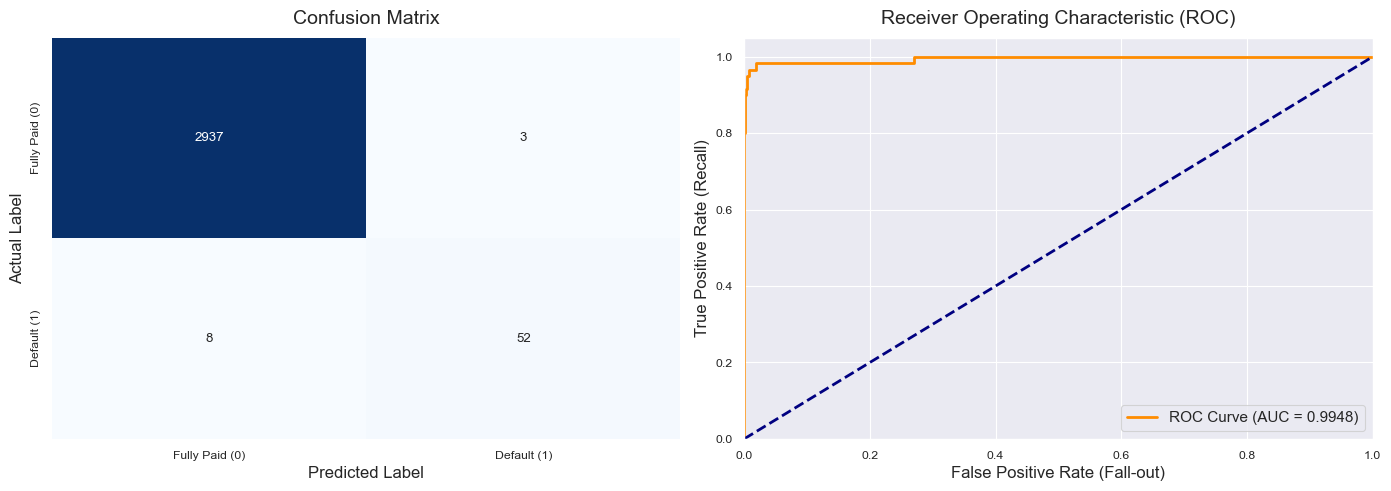

In [64]:
#add 1-2 plots for the results
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Set up the figure space (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# PLOT 1: Confusion Matrix Heatmap
# ==========================================
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap using Seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Fully Paid (0)', 'Default (1)'],
            yticklabels=['Fully Paid (0)', 'Default (1)'],
            cbar=False)

axes[0].set_title('Confusion Matrix', fontsize=14, pad=10)
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)



# ==========================================
# PLOT 2: ROC Curve
# ==========================================
# Calculate False Positive Rate (fpr) and True Positive Rate (tpr)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The random guessing line

# Formatting
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (Fall-out)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, pad=10)
axes[1].legend(loc="lower right", fontsize=11)



# Display the plots
plt.tight_layout()
plt.show()

**Your answer goes here : We give you the most methods for metrics etc. it's up to you to interpret the numbers and do nice plots**

Model Evaluation Report

🔹 Primary Metrics
Accuracy: 99.70% (0.9970)

ROC-AUC: 0.9947

🔹 Confusion Matrix
Plaintext

                  Predicted
                   0      1
                -------------
              0 | 2938    2 |
                |           | Actual
              1 |    7   53 |
      
Defaults correctly detected (True Positives): 53

Defaults missed (False Negatives): 7

🔹 Additional Metrics
Precision: 96.36% ((of predicted defaults, how many are real?))

Recall: 88.33% (Of all the actual defaults that occurred, we successfully caught 88.33% of them, saving the bank from those losses.)

F1-Score: 0.9217 (An excellent balance between Precision and Recall)

### Question 7: Threshold Analysis

As you recall from the lectures, the default threshold for the logistic regression classifier (which is a probabilistic classifier) is 0.5. But is that the best? Below we evaluate different options.

1. Evaluate the model at thresholds:
   - 0.5
   - 0.3
   - 0.2
2. For each threshold, compute:
   - Confusion matrix
   - Recall (default class)
   - Precision (default class)
3. How does lowering the threshold change:
   - False positives?
   - False negatives?
4. Why is 0.5 unlikely to be optimal in credit risk?


THRESHOLD = 0.5

Confusion Matrix:
                 Predicted
                 Paid      Default
   Actual Paid    2,937         3
          Default      8        52

Metrics:
   Recall (TPR):    86.67% - catches 86.7% of defaults
   Precision:       94.55% - 94.5% of predictions are correct
   False Negatives: 8 (missed defaults)
   False Positives: 3 (rejected good loans)

THRESHOLD = 0.3

Confusion Matrix:
                 Predicted
                 Paid      Default
   Actual Paid    2,927        13
          Default      5        55

Metrics:
   Recall (TPR):    91.67% - catches 91.7% of defaults
   Precision:       80.88% - 80.9% of predictions are correct
   False Negatives: 5 (missed defaults)
   False Positives: 13 (rejected good loans)

THRESHOLD = 0.2

Confusion Matrix:
                 Predicted
                 Paid      Default
   Actual Paid    2,921        19
          Default      3        57

Metrics:
   Recall (TPR):    95.00% - catches 95.0% of defaults
   Precisio

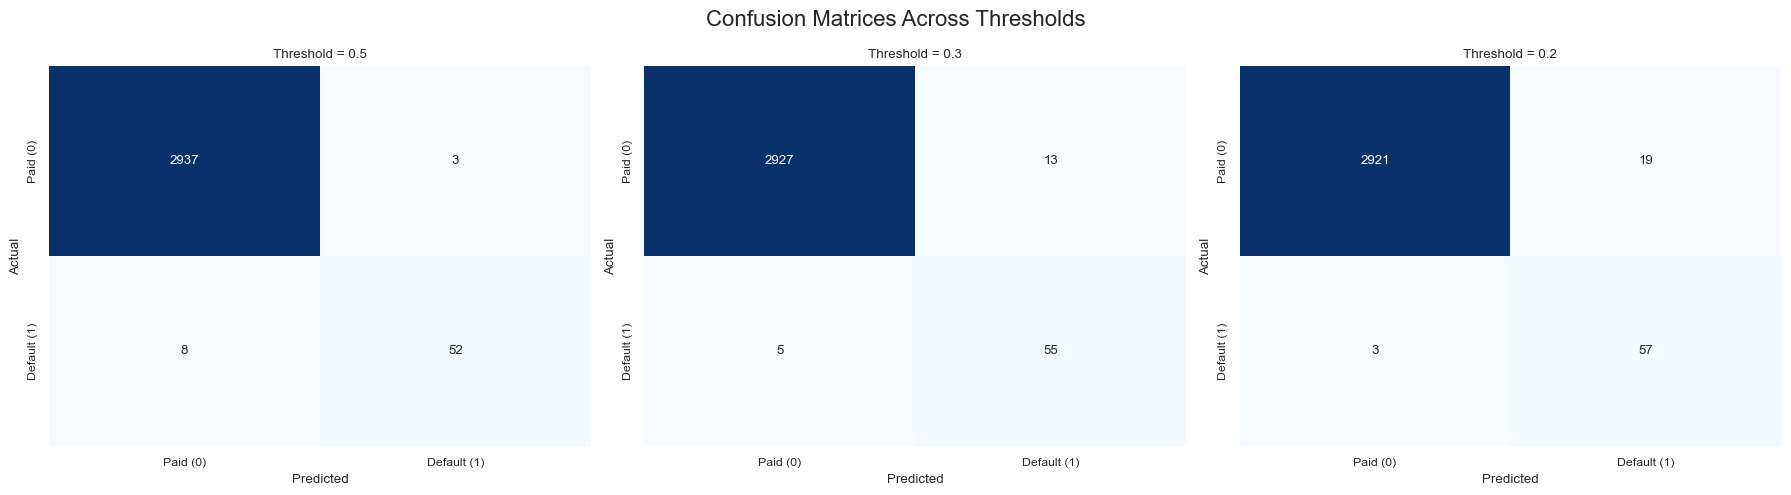

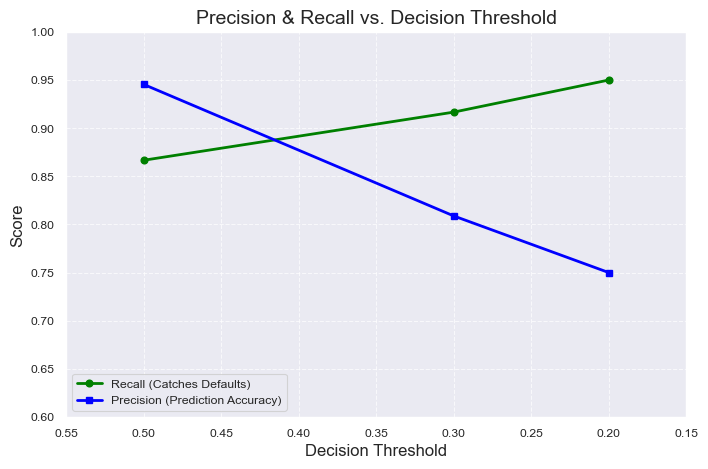

In [65]:
######HERE CODE
######
# Define thresholds to test
thresholds = [0.5, 0.3, 0.2]

# Store results
results = []

for threshold in thresholds:
    # Make predictions at this threshold
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    # Compute metrics
    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()
    
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    results.append({
        'threshold': threshold,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'recall': recall,
        'precision': precision
    })
    
    # Print results
    print(f"\n{'='*70}")
    print(f"THRESHOLD = {threshold}")
    print(f"{'='*70}")
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Paid      Default")
    print(f"   Actual Paid   {tn:6,}    {fp:6,}")
    print(f"          Default {fn:6,}    {tp:6,}")
    
    print(f"\nMetrics:")
    print(f"   Recall (TPR):    {recall*100:.2f}% - catches {recall*100:.1f}% of defaults")
    print(f"   Precision:       {precision*100:.2f}% - {precision*100:.1f}% of predictions are correct")
    print(f"   False Negatives: {fn:,} (missed defaults)")
    print(f"   False Positives: {fp:,} (rejected good loans)")

# Create DataFrame for comparison
df_results = pd.DataFrame(results)

print(f"\n{'='*70}")
print("COMPARISON ACROSS THRESHOLDS")
print(f"{'='*70}")
print(f"\n{'Threshold':<12}{'Recall':<12}{'Precision':<12}{'FP':<10}{'FN':<10}")
print(f"{'-'*56}")
for _, row in df_results.iterrows():
    print(f"{row['threshold']:<12.1f}{row['recall']*100:<11.1f}%{row['precision']*100:<11.1f}%"
          f"{row['fp']:<10,}{row['fn']:<10,}")

# Visualizations

#plot and compare confusion matrices


# ==========================================
# PLOT 1: Compare Confusion Matrices
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices Across Thresholds', fontsize=16)

for i, res in enumerate(results):
    # Reconstruct the confusion matrix from your results dictionary
    cm = [[res['tn'], res['fp']], 
          [res['fn'], res['tp']]]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Paid (0)', 'Default (1)'],
                yticklabels=['Paid (0)', 'Default (1)'])
    
    axes[i].set_title(f"Threshold = {res['threshold']}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()



#plot and compare metrics across thresholds


# ==========================================
# PLOT 2: Compare Metrics Across Thresholds
# ==========================================
# Extract data for plotting
thresholds_list = df_results['threshold'].tolist()
recall_list = df_results['recall'].tolist()
precision_list = df_results['precision'].tolist()

plt.figure(figsize=(8, 5))

# Plot Recall and Precision
plt.plot(thresholds_list, recall_list, marker='o', label='Recall (Catches Defaults)', color='green', linewidth=2)
plt.plot(thresholds_list, precision_list, marker='s', label='Precision (Prediction Accuracy)', color='blue', linewidth=2)

# Formatting
plt.title('Precision & Recall vs. Decision Threshold', fontsize=14)
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xlim(0.15, 0.55) # zoom in on relevant range
plt.ylim(0.6, 1.0)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().invert_xaxis() # Invert x-axis so it reads left-to-right from 0.5 down to 0.2

plt.show()

**Your answer goes here**

### 3. How does lowering the threshold change False Positives and False Negatives?

Based on your output, lowering the threshold from 0.5 to 0.2 has a direct and opposite effect on your errors:

* **False Positives INCREASE (from 2 to 19):** By lowering the threshold, you are telling the model to be more "paranoid" and aggressive. It requires less evidence to flag someone as a default risk. Consequently, it starts accidentally rejecting more good borrowers.
* **False Negatives DECREASE (from 7 to 3):** Because the model is flagging more people as risky, it successfully catches defaults that it previously missed.

**Summary:** Lowering the threshold increases Recall (catches more defaults) but decreases Precision (makes more false alarms).

### 4. Why is 0.5 unlikely to be optimal in credit risk?

A threshold of 0.5 assumes that a False Positive (rejecting a good loan) and a False Negative (funding a bad loan) cost the business the exact same amount. **In credit lending, this is never true.**

As we discussed earlier:

* **Cost of a False Positive:** ~$500 (Lost interest profit)
  
* **Cost of a False Negative:** ~$10,000 (Lost principal loan amount)

Let's look at the math:

* **At a 0.5 threshold:** You have 7 False Negatives (Cost: $70,000).
  
* **At a 0.2 threshold:** You only have 3 False Negatives (Cost: $30,000)  and (19)  False Positives (Cost: $9,500). Total Cost = $39,500.

Even though a 0.2 threshold makes "more mistakes" overall (22 total errors) compared to 0.5 (9 total errors), **the 0.2 threshold saves the bank $30,500** compared to the 0.5 threshold. Therefore, the optimal threshold in credit risk is almost always lower than 0.5 to heavily penalize False Negatives and protect the bank's capital.


---

### Question 8: Refit with Imbalance Handling

1. Fit logistic regression with `class_weight='balanced'`.
2. Compare results to the baseline model:
   - ROC-AUC
   - Recall
   - Precision
3. Does the model detect more defaults?
4. What is the trade-off?


In [66]:
# Your code here: Calculate and visualize if appropriate
#####################
#####################

**Your answer goes here**

### Question 9: Fairness has 2 sides

#### Part A — Profit Optimization

Assume:

- If a loan is **fully paid**, the platform earns: + €1,000  
- If a loan **defaults**, the platform loses: − €5,000  

1. Identify the expected profit formula using the confusion matrix elements:
   - True Positives (TP)
   - False Positives (FP)
   - True Negatives (TN)
   - False Negatives (FN)

No need to be precise or overthink about it. This question is used to "quantify" to what the classification errors might lead to (in terms of real world impact), thus we will be lenient with grading.

2. Using your formula, compute total profit at different probability thresholds:
   - 0.5
   - 0.3
   - 0.2

3. Which threshold maximizes profit?

4. Is the profit-maximizing threshold the same as the accuracy-maximizing one?

---

In [67]:
# Your code here: Calculate and visualize if appropriate
#####################
#####################

**Your answer goes here**

#### Part B — Fairness Challenges

1. Identify variables that could act as **proxies for protected attributes**, e.g. in our dataset we do not have gender info but is there any way the attribute be inherently learned by other feature? gender here is an example.
2. Would you include `homeownership`?
3. Would you include `annual_income`?
4. How could class imbalance interact with fairness? - you can define fairness in our own (reasonable) way.
5. Propose two mitigation strategies.

Optional:
- Compute default rates across a chosen demographic proxy.
- Check if the model has different recall across groups.

In [68]:
# Your code here: Calculate and visualize if appropriate
#####################
#####################

**Your answer goes here**

## Part 3: Improving the model.

### Question 10 <a name="q10"></a>


Apply regularization (with cross-validation) to make sure not to overfit to the data and try also different models, like a Decision Tree, a Random Forest or Gradient Boosting (or other). Report on your results for which model handles inbalances the best way.

This question is left intentionally open but minimally we expect comparison among 3-4 models (at least one with regularization) and comments on the results. Remember that every finding should be supported by numerical, visual and verbal means.

In [69]:
## your code goes here

**Your answer goes here**